In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel(r"/content/smart_dam_dataset_updated.xlsx")

In [ ]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 timestamp           0
rainfall            0
inflow              0
outflow             0
water_level         0
pressure            0
water_level_prev    0
rain_avg_3h         0
gate_status         0
risk                0
dtype: int64


In [ ]:
df['risk'] = df['risk'].str.upper()
df['risk'] = df['risk'].map({
    'SAFE': 0,
    'WARNING': 1,
    'DANGER': 2
})

In [ ]:
print("\nData Types:\n", df.dtypes)


Data Types:
 timestamp            object
rainfall            float64
inflow              float64
outflow             float64
water_level         float64
pressure            float64
water_level_prev    float64
rain_avg_3h         float64
gate_status           int64
risk                  int64
dtype: object


In [ ]:
print("\nCleaned Data Preview:\n", df.head())


Cleaned Data Preview:
              timestamp  rainfall    inflow   outflow  water_level   pressure  \
0  2025-01-01 01:00:00  5.300915  5.543026  2.027209    49.893820  49.564600   
1  2025-01-01 02:00:00  0.000000  0.000000  0.911898    49.968251  47.241833   
2  2025-01-01 03:00:00  0.000000  0.000000  0.573384    49.877061  48.972287   
3  2025-01-01 04:00:00  9.014899  9.461149  2.810452    49.819722  46.166041   
4  2025-01-01 05:00:00  2.262156  1.814820  0.539932    50.011735  47.284456   

   water_level_prev  rain_avg_3h  gate_status  risk  
0         50.000000     5.300915            1     0  
1         49.893820     1.766972            0     0  
2         49.968251     1.766972            0     0  
3         49.877061     3.004966            1     1  
4         49.819722     3.759018            0     0  


In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)

print("\nData Cleaning Completed Successfully!")


Data Cleaning Completed Successfully!


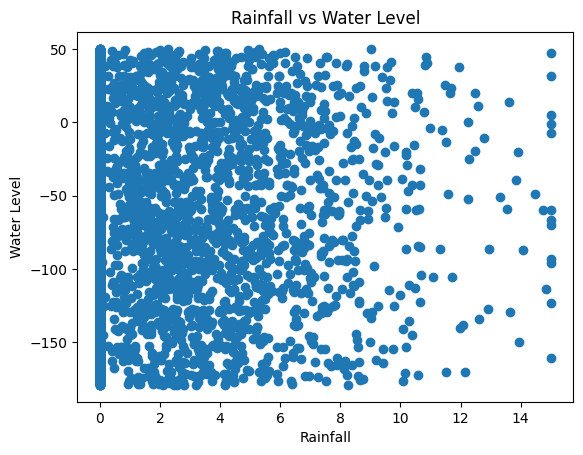

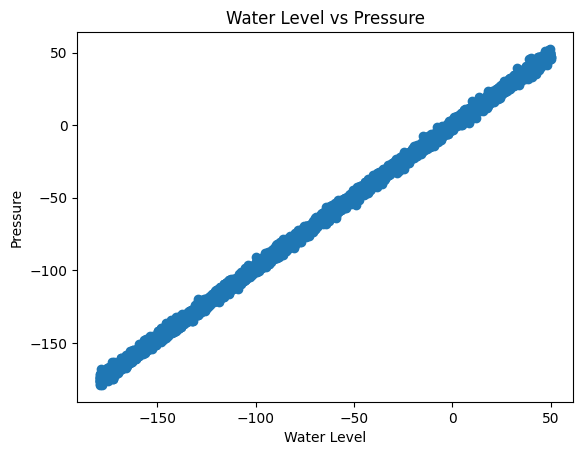

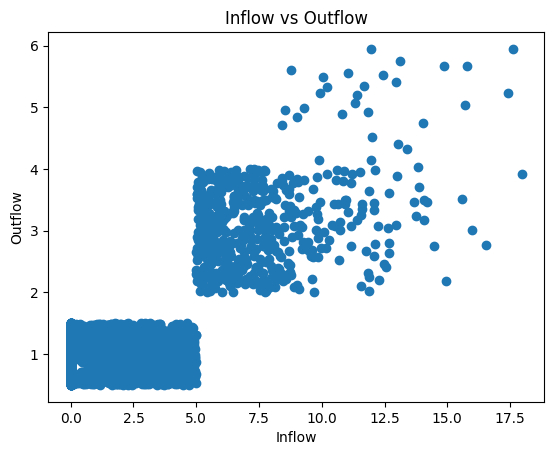

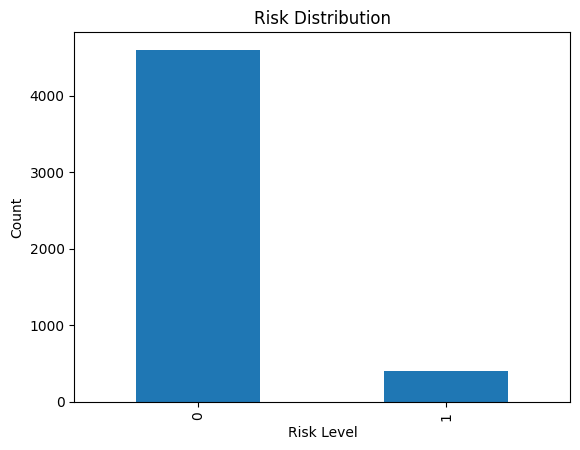

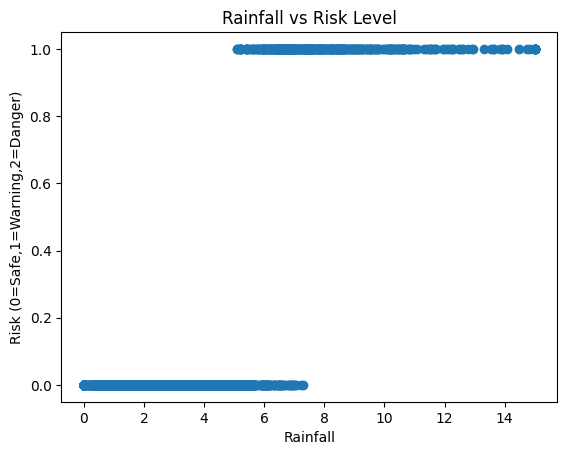

In [ ]:
plt.figure()
plt.scatter(df['rainfall'], df['water_level'])
plt.xlabel("Rainfall")
plt.ylabel("Water Level")
plt.title("Rainfall vs Water Level")
plt.show()

plt.figure()
plt.scatter(df['water_level'], df['pressure'])
plt.xlabel("Water Level")
plt.ylabel("Pressure")
plt.title("Water Level vs Pressure")
plt.show()

plt.figure()
plt.scatter(df['inflow'], df['outflow'])
plt.xlabel("Inflow")
plt.ylabel("Outflow")
plt.title("Inflow vs Outflow")
plt.show()


plt.figure()
df['risk'].value_counts().plot(kind='bar')
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.title("Risk Distribution")
plt.show()


plt.figure()
plt.scatter(df['rainfall'], df['risk'])
plt.xlabel("Rainfall")
plt.ylabel("Risk (0=Safe,1=Warning,2=Danger)")
plt.title("Rainfall vs Risk Level")
plt.show()

ML MODEL BUILDING

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

In [ ]:
!pip install xgboost tensorflow

In [ ]:

df.head()

,timestamp,rainfall,inflow,outflow,water_level,pressure,water_level_prev,rain_avg_3h,gate_status,risk
0,2025-01-01 01:00:00,5.300915,5.543026,2.027209,49.893820,49.564600,50.000000,5.300915,1,0
1,2025-01-01 02:00:00,0.000000,0.000000,0.911898,49.968251,47.241833,49.893820,1.766972,0,0
2,2025-01-01 03:00:00,0.000000,0.000000,0.573384,49.877061,48.972287,49.968251,1.766972,0,0
3,2025-01-01 04:00:00,9.014899,9.461149,2.810452,49.819722,46.166041,49.877061,3.004966,1,1
4,2025-01-01 05:00:00,2.262156,1.814820,0.539932,50.011735,47.284456,49.819722,3.759018,0,0


In [ ]:

df['timestamp'] = pd.to_datetime(df['timestamp'])


le = LabelEncoder()
df['risk_encoded'] = le.fit_transform(df['risk'])

df_model = df.drop(['timestamp', 'risk'], axis=1)

X = df_model.drop(['water_level', 'risk_encoded'], axis=1)
y_reg = df_model['water_level']
y_clf = df_model['risk_encoded']

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

LIGHTGBM IMPLEMENTATION

In [ ]:
!pip install lightgbm

In [ ]:
import lightgbm as lgb

In [ ]:
# LightGBM Regressor
lgb_reg = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1)

lgb_reg.fit(X_train, y_train_reg)

lgb_pred = lgb_reg.predict(X_test)

from sklearn.metrics import mean_squared_error
import numpy as np

print("LightGBM RMSE:",
      np.sqrt(mean_squared_error(y_test_reg, lgb_pred)))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002343 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1533
[LightGBM] [Info] Number of data points in the train set: 3999, number of used features: 7
[LightGBM] [Info] Start training from score -61.656359
LightGBM RMSE: 0.33150950008344493


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# LightGBM Classifier
lgb_clf = lgb.LGBMClassifier(n_estimators=100)

lgb_clf.fit(X_train, y_train_clf)

lgb_pred_clf = lgb_clf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("\n LightGBM Classification")
print("Accuracy:", accuracy_score(y_test_clf, lgb_pred_clf))
print(classification_report(y_test_clf, lgb_pred_clf))

[LightGBM] [Info] Number of positive: 326, number of negative: 3673
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000581 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1533
[LightGBM] [Info] Number of data points in the train set: 3999, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.081520 -> initscore=-2.421867
[LightGBM] [Info] Start training from score -2.421867
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


XGBOOST

In [ ]:
from xgboost import XGBRegressor, XGBClassifier

xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb_reg.fit(X_train, y_train_reg)

xgb_pred = xgb_reg.predict(X_test)

print("🔹 XGBoost Regression RMSE:",
      np.sqrt(mean_squared_error(y_test_reg, xgb_pred)))

xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_clf.fit(X_train, y_train_clf)

xgb_pred_clf = xgb_clf.predict(X_test)

print("\n🔹 XGBoost Classification")
print("Accuracy:", accuracy_score(y_test_clf, xgb_pred_clf))
print(classification_report(y_test_clf, xgb_pred_clf))

🔹 XGBoost Regression RMSE: 0.3192661006209203

🔹 XGBoost Classification
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       927
           1       1.00      1.00      1.00        73

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:15:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


LSTM-(Time series)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

X_array = X.values
y_array = y_reg.values

def create_sequences(X, y, time_steps=5):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 5
X_seq, y_seq = create_sequences(X_array, y_array, time_steps)

split = int(0.8 * len(X_seq))

X_train_lstm, X_test_lstm = X_seq[:split], X_seq[split:]
y_train_lstm, y_test_lstm = y_seq[:split], y_seq[split:]

In [ ]:
model = Sequential([
    LSTM(50, activation='relu', input_shape=(time_steps, X.shape[1])),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=32)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 157.4503
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.3221
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.2135
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.1462
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0978
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0887
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0657
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0539
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0456
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0362


In [ ]:
lstm_pred = model.predict(X_test_lstm)

print(" LSTM RMSE:",
      np.sqrt(mean_squared_error(y_test_lstm, lstm_pred)))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
 LSTM RMSE: 0.2520157652471827


HYBRID MODEL CODE

In [ ]:
lstm_pred = model.predict(X_test_lstm).flatten()

xgb_pred = xgb_reg.predict(X_test)

lgb_pred = lgb_reg.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
lstm_pred = lstm_pred.flatten()
xgb_pred = np.array(xgb_pred)
lgb_pred = np.array(lgb_pred)

min_len = min(len(lstm_pred), len(xgb_pred), len(lgb_pred), len(y_test_reg))

lstm_pred = lstm_pred[-min_len:]
xgb_pred = xgb_pred[-min_len:]
lgb_pred = lgb_pred[-min_len:]
y_true = y_test_reg.values[-min_len:]

w_lstm = 0.4
w_xgb = 0.3
w_lgb = 0.3

hybrid_pred = (
    w_lstm * lstm_pred +
    w_xgb * xgb_pred +
    w_lgb * lgb_pred
)

from sklearn.metrics import mean_squared_error
import numpy as np

print(" Hybrid RMSE:",
      np.sqrt(mean_squared_error(y_true, hybrid_pred)))

 Hybrid RMSE: 46.56998745926242


In [ ]:
w_lstm = 0.4
w_xgb = 0.3
w_lgb = 0.3

hybrid_pred = (
    w_lstm * lstm_pred +
    w_xgb * xgb_pred +
    w_lgb * lgb_pred
)

from sklearn.metrics import mean_squared_error
import numpy as np

print(" Weighted Hybrid RMSE:",
      np.sqrt(mean_squared_error(y_true, hybrid_pred)))

 Weighted Hybrid RMSE: 46.56998745926242


Comparison between the models

In [ ]:
from sklearn.metrics import mean_squared_error, accuracy_score

xgb_rmse = np.sqrt(mean_squared_error(y_test_reg, xgb_reg.predict(X_test)))
lgb_rmse = np.sqrt(mean_squared_error(y_test_reg, lgb_reg.predict(X_test)))
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm, lstm_pred[:len(y_test_lstm)]))
hybrid_rmse = np.sqrt(mean_squared_error(y_test_reg[:len(hybrid_pred)], hybrid_pred))

print("\nMODEL COMPARISON (RMSE):")
print("XGBoost RMSE:", xgb_rmse)
print("LightGBM RMSE:", lgb_rmse)

print("LSTM RMSE:", lstm_rmse)
print("Hybrid RMSE:", hybrid_rmse)


MODEL COMPARISON (RMSE):
XGBoost RMSE: 0.3192661006209203
LightGBM RMSE: 0.33150950008344493
LSTM RMSE: 0.2520157652471827
Hybrid RMSE: 86.41238967918594


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Visualising the Output

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


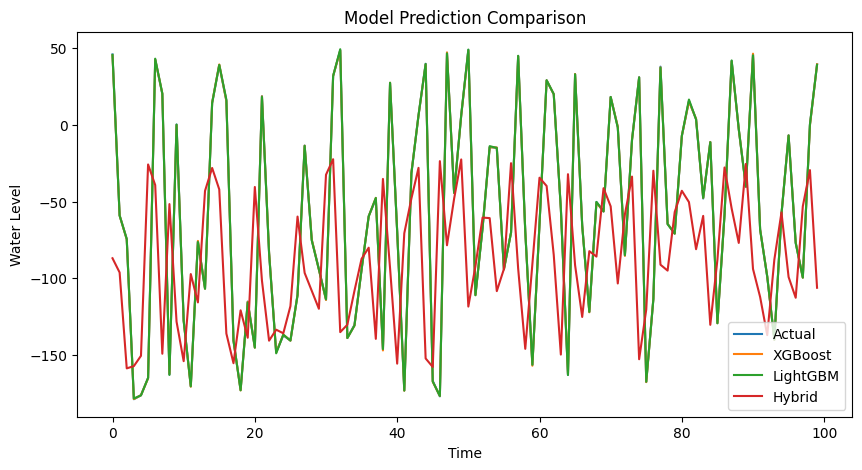

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test_reg.values[:100], label="Actual")
plt.plot(xgb_reg.predict(X_test)[:100], label="XGBoost")
plt.plot(lgb_reg.predict(X_test)[:100], label="LightGBM")
plt.plot(hybrid_pred[:100], label="Hybrid")

plt.legend()
plt.title("Model Prediction Comparison")
plt.xlabel("Time")
plt.ylabel("Water Level")
plt.show()

In [ ]:
def classify_risk(water_level):
    if water_level < 30:
        return "SAFE"
    elif water_level < 50:
        return "WARNING"
    else:
        return "DANGER"

# Apply on hybrid output
risk_output = [classify_risk(x) for x in hybrid_pred]

print("\nSample Final Output:")
for i in range(10):
    print(f"Predicted Level: {hybrid_pred[i]:.2f} --> {risk_output[i]}")


Sample Final Output:
Predicted Level: -87.00 --> SAFE
Predicted Level: -96.28 --> SAFE
Predicted Level: -158.81 --> SAFE
Predicted Level: -157.33 --> SAFE
Predicted Level: -150.62 --> SAFE
Predicted Level: -25.81 --> SAFE
Predicted Level: -39.28 --> SAFE
Predicted Level: -149.26 --> SAFE
Predicted Level: -51.67 --> SAFE
Predicted Level: -128.35 --> SAFE


In [ ]:
new_data = pd.DataFrame({
    'rainfall': [120],
    'temperature': [28],
    'humidity': [85],
    'inflow': [300],
    'outflow': [150],
    'pressure': [500],
    'water_level_prev': [45]
})

xgb_out = xgb_reg.predict(new_data)
lgb_out = lgb_reg.predict(new_data)

new_lstm = np.array(new_data).reshape((1,1,new_data.shape[1]))
lstm_out = model.predict(new_lstm)[0][0]

final_pred = 0.4*lstm_out + 0.3*xgb_out[0] + 0.3*lgb_out[0]

print("\nREAL-TIME PREDICTION:")
print("Water Level:", final_pred)
print("Risk Level:", classify_risk(final_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step

REAL-TIME PREDICTION:
Water Level: 44.657739315280715
Risk Level: WARNING


TESTING

In [ ]:
print("Training features:", len(X.columns))
print("Input features:", len(new_data.columns))

Training features: 7
Input features: 7


In [ ]:
print("XGB:", xgb_out)
print("LGB:", lgb_out)
print("LSTM:", lstm_out)
print("Hybrid:", final_pred)

XGB: [49.258835]
LGB: [49.36972828]
LSTM: 37.672928
Hybrid: 44.657739315280715


In [ ]:
print("Final Water Level:", final_pred)
print("Risk Level:", classify_risk(final_pred))

Final Water Level: 44.657739315280715
Risk Level: WARNING
